## Imports

In [5]:
import sys
import os

module_path = os.path.abspath(os.path.join('..', 'src'))
sys.path.insert(0, module_path)

In [7]:
import pandas as pd
import plotly.express as px
import numpy as np
import json

from src.analysis.converters import convert_transitions_to_state_counts, convert_transitions_to_agent_states
from src.models.seir import SEIRNeighborsFSMExtended

## Load data

In [55]:
sim_dt = "2025-12-02-235259Z"
sim_data_filename = f"../simulation_data/project_practice/SEIR_Neighbors_Project_Practice_Simulation_Transitions-{sim_dt}.csv"
sim_params_filename = f"../simulation_data/project_practice/SEIR_Neighbors_Project_Practice_Simulation_Params-{sim_dt}.json"
neighbors = pd.read_csv(
    "../simulation_conditions_data/neighbors/NeighborsMap-100by100-Agents10000-Neighbors20-2025-10-07-005129Z.csv"
)

In [56]:
with open(sim_params_filename, "r") as file:
    sim_params = json.load(file)
sim_params

{'random_seed': 42,
 'n_agents': 10000,
 'sim_duration': 365,
 'output_path': 'simulation_data/project_practice',
 'initially_infected': 5,
 'age_params': {'age_ranges': {'0': [0, 9],
   '1': [10, 19],
   '2': [20, 29],
   '3': [30, 39],
   '4': [40, 49],
   '5': [50, 59],
   '6': [60, 69],
   '7': [70, 79],
   '8': [80, 89],
   '9': [90, 100]},
  'age_probs': {'0': 0.1125,
   '1': 0.15,
   '2': 0.2,
   '3': 0.15,
   '4': 0.2,
   '5': 0.1,
   '6': 0.05,
   '7': 0.025,
   '8': 0.00625,
   '9': 0.00625},
  'immunity_reduction_factors': {'0': 0.2,
   '1': 0.05,
   '2': 0.0,
   '3': 0.0,
   '4': 0.05,
   '5': 0.1,
   '6': 0.15,
   '7': 0.2,
   '8': 0.25,
   '9': 0.3}},
 'immunity_params': {'lowest_immunity': 0.1,
  'highest_immunity': 1.0,
  'mask_beta_penalty': 0.5,
  'mask_discipline_worst': 0.0,
  'mask_discipline_best': 0.9},
 'beta': 0.03,
 'e1': 5,
 'e2': 10,
 't1': 14,
 't2': 21,
 'pathogen_config': {},
 'pollutants_config': {'pollutant_immunity_reduction': 0.1,
  'pollutant_exposur

In [57]:
transitions_df = pd.read_csv(sim_data_filename)
transitions_df.head()

,time,agent,event,source_state,dest_state
0,0,40,transition,susceptible,infected
1,0,101,transition,susceptible,infected
2,0,200,transition,susceptible,infected
3,0,300,transition,susceptible,infected
4,0,1050,transition,susceptible,infected


In [58]:
states = [state.name for state in SEIRNeighborsFSMExtended.states]

In [59]:
state_counts_df = convert_transitions_to_state_counts(transitions_df=transitions_df,
                                                       states=states,
                                                       initial_state=states[0],
                                                       n_agents=sim_params['n_agents'],
                                                       sim_duration=sim_params['sim_duration'])

## Simulation Params

In [60]:
N_AGENTS = sim_params['n_agents']
BETA = sim_params['beta']
SIM_DURATION = sim_params['sim_duration']

## Visualization

### Style

In [61]:
color_map = {"susceptible": "#8da0cb", "infected": "#fc8d62", "recovered": "#66c2a5"}
title_text = f"SEIR Neighbor Agent Model<br>β={BETA}, Population Size={N_AGENTS}"

legend_params = dict(
    orientation="h",
    yanchor="bottom",
    y=-.3,
    xanchor="center",
    x=0.5,
    title_text="")

title_params = dict(text=title_text, font_size=20)

graph_params = dict(
    title=title_params,
    legend=legend_params,
    width=1000,
    height=500,
    template="presentation")

### Area Plot

In [62]:
groups = [g for g in state_counts_df.columns if g != 'time']

timeline_df = (
    state_counts_df
    .melt(id_vars=['time'], value_vars=groups, var_name="grp", value_name="count")
    .assign(grp=lambda _df: pd.Categorical(_df.grp, categories=groups, ordered=True))
    .sort_values(by=["time", "grp"], ascending=[True, False])
    .reset_index(drop=True)
)
timeline_df.head(5)

,time,grp,count
0,0,recovered,0
1,0,infected,5
2,0,exposed,0
3,0,susceptible,9995
4,1,recovered,0


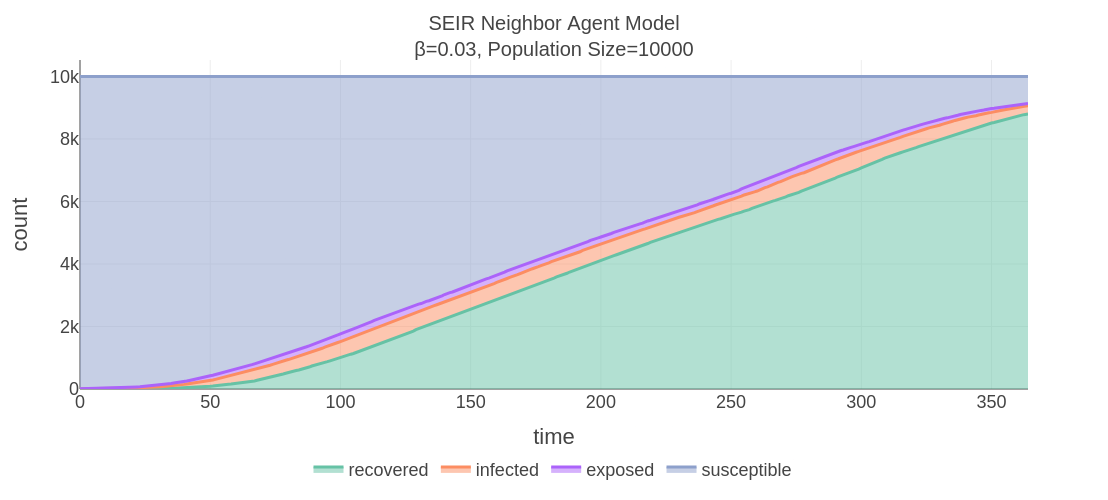

In [63]:
fig = px.area(timeline_df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params)
fig.show()

### Line Plot

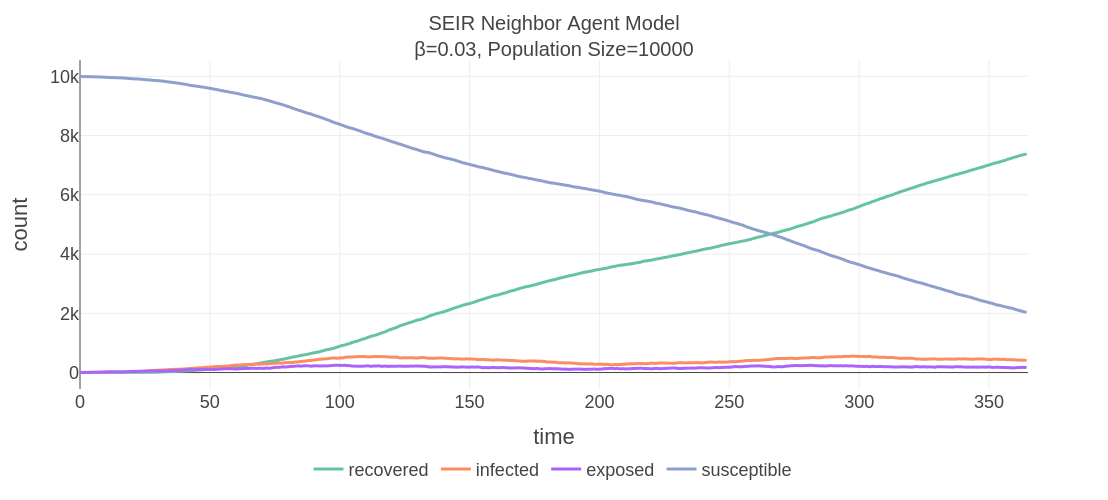

In [54]:
fig = px.line(timeline_df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 365])
fig.show()

### Line plot animated

In [39]:
df2 = (
    state_counts_df
    .sort_values(by=["time"])
    .reset_index(drop=True)
    .head(365)
)

In [40]:
def create_animation_df(source_df, start=10, frame_cnt=SIM_DURATION, speed_up=1):
    target_df = pd.DataFrame()
    frame_cnt = int(frame_cnt / speed_up)
    for i in np.arange(start, frame_cnt):
        dfa = source_df.head(i * speed_up).copy()
        dfa['ix'] = i
        target_df = pd.concat([target_df, dfa])
    return target_df

In [41]:
animation_df = create_animation_df(df2, start=0, frame_cnt=df2.shape[0], speed_up=1)

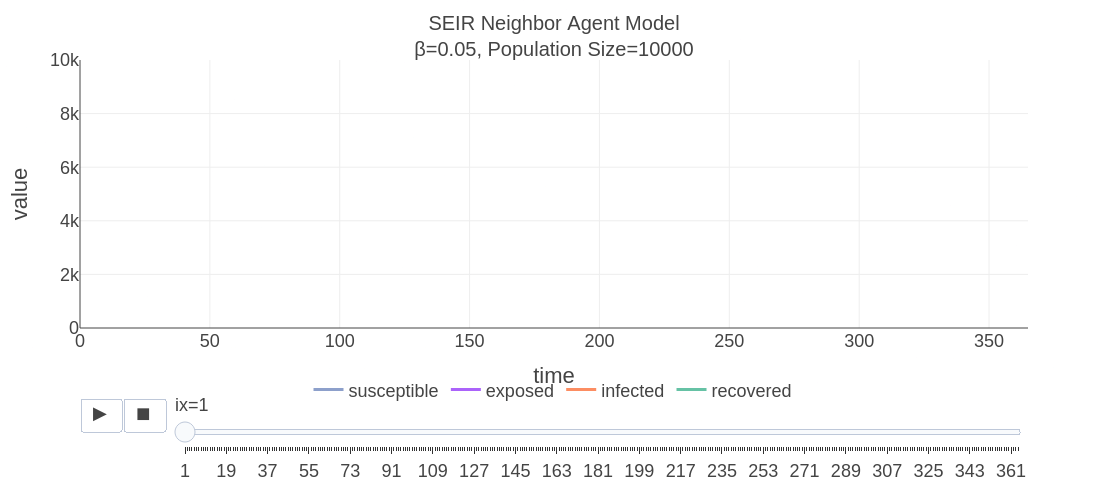

In [44]:
fig = px.line(animation_df,
              x="time",
              y=groups,
              animation_frame="ix",
              color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 365], yaxis_range=[0, 10000])
fig.layout.updatemenus[0].buttons[0]['args'][1]['frame']['redraw'] = True
fig.show()